In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

In [2]:
np.random.seed(123)

trials = 4
theta_real = 0.35
data = pz.Binomial(n=1, p=theta_real).rvs(trials)
display(data)

array([1, 0, 0, 0])

In [3]:
with pm.Model() as our_first_model:
    theta = pm.Beta('theta', alpha=1., beta=1.)
    y = pm.Bernoulli('y', p=theta, observed=data)
    idata = pm.sample(1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [4]:
display(idata)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

array([[<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}>]], dtype=object)

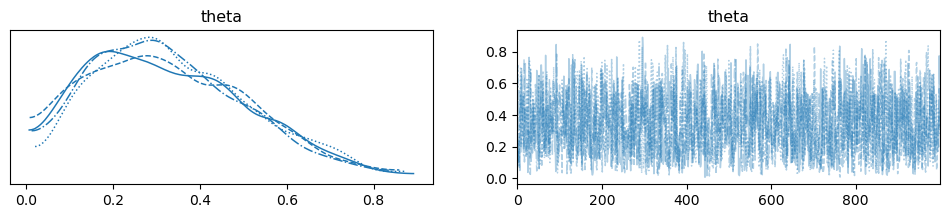

In [5]:
az.plot_trace(idata)

array([[<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}, xlabel='Rank (all chains)', ylabel='Chain'>]],
      dtype=object)

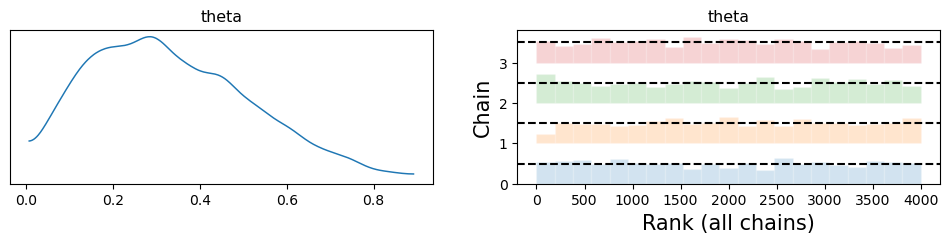

In [6]:
az.plot_trace(idata, kind='rank_bars', combined=True)

array([[<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}, xlabel='Rank (all chains)'>]],
      dtype=object)

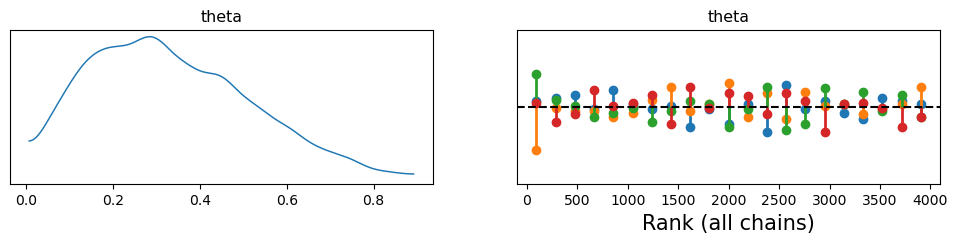

In [7]:
az.plot_trace(idata, kind='rank_vlines', combined=True)

In [8]:
az.summary(idata, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
theta,0.33,0.18,0.02,0.65


<Axes: title={'center': 'theta'}>

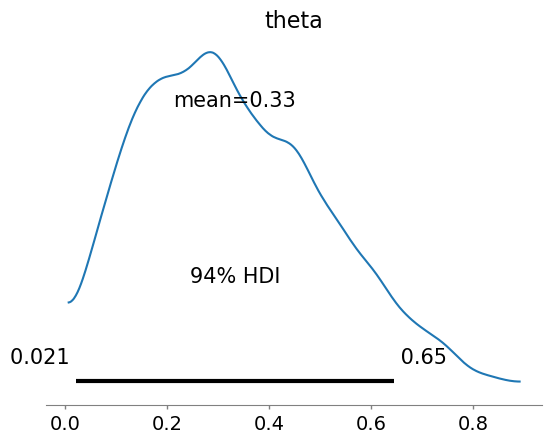

In [9]:
az.plot_posterior(idata)

({'BF10': 0.799698605854951, 'BF01': 1.2504711058373155},
 <Axes: title={'center': 'The BF_10 is 0.80\nThe BF_01 is 1.25'}, xlabel='theta', ylabel='Density'>)

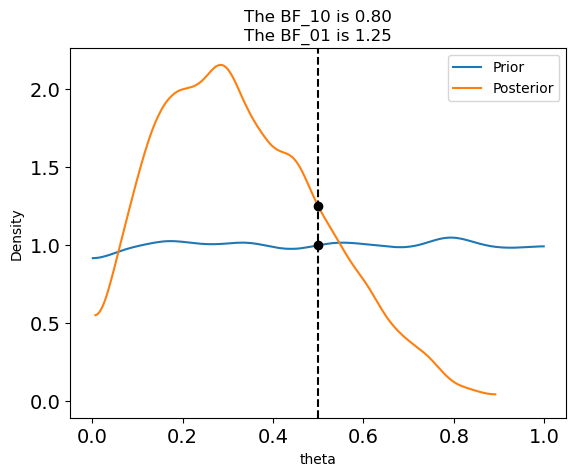

In [10]:
az.plot_bf(idata, var_name="theta", 
           prior=np.random.beta(1, 1, 10000), ref_val=0.5)

({'BF10': 0.7998405642151657, 'BF01': 1.2502491680716874},
 <Axes: title={'center': 'The BF_10 is 0.80\nThe BF_01 is 1.25'}, xlabel='theta', ylabel='Density'>)

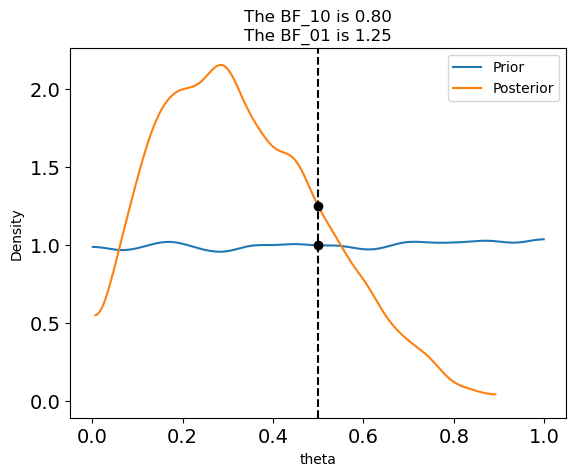

In [11]:
az.plot_bf(idata, var_name="theta", 
           prior=np.random.uniform(0, 1, 10000), ref_val=0.5)

<Axes: title={'center': 'theta'}>

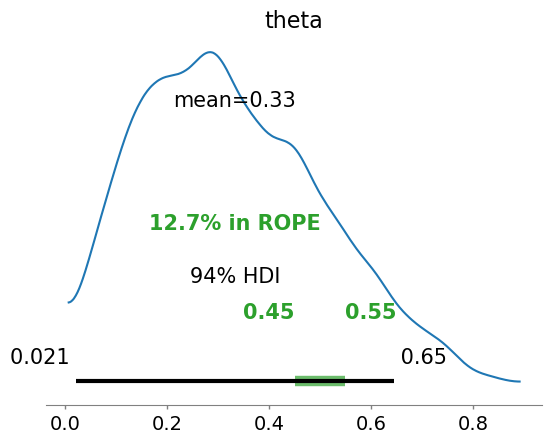

In [12]:
az.plot_posterior(idata, rope=[0.45, 0.55])

<Axes: title={'center': 'theta'}>

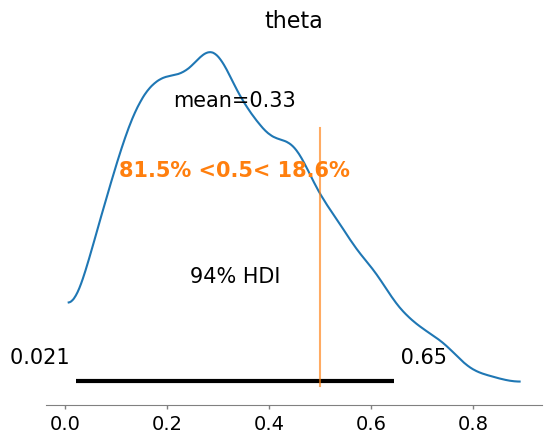

In [13]:
az.plot_posterior(idata, ref_val=0.5)

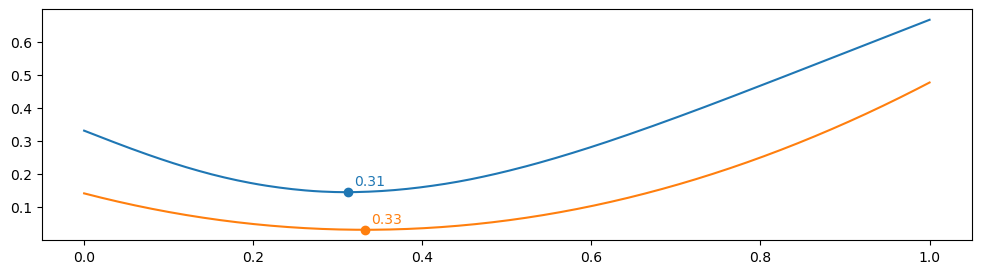

In [14]:
grid = np.linspace(0, 1, 200)
theta_pos = idata.posterior['theta']
loss_a = [np.mean(abs(i - theta_pos)) for i in grid]
loss_b = [np.mean((i - theta_pos)**2) for i in grid]
_, ax = plt.subplots(figsize=(12, 3))
for lossf, c in zip([loss_a, loss_b], ['C0', 'C1']):
    mini = np.argmin(lossf)
    ax.plot(grid, lossf, color=c)
    ax.plot(grid[mini], lossf[mini], 'o', color=c)
    ax.annotate(f"{grid[mini]:.2f}", (grid[mini], lossf[mini]), xytext=(5, 5),
                textcoords="offset points", color=c)



In [15]:
display(np.mean(theta_pos).round(2), np.median(theta_pos).round(2))


<xarray.DataArray 'theta' ()>
array(0.33)

0.31

Text(0.5, 0, '$\\hat \\theta$')

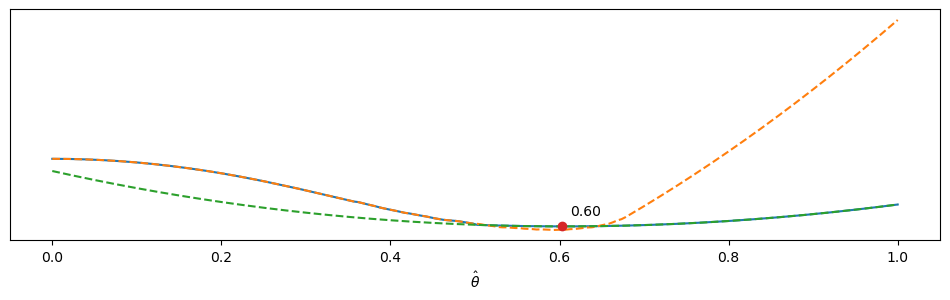

In [16]:
# 각 i 값에 대해 손실 함수를 계산합니다.
from matplotlib import style
from pyparsing import line


lossf = []
for i in grid:
    # i가 0.5 미만인 경우: 중앙값을 사용한 손실 계산
    if i < 0.5:
        f = 1 / np.median(theta_pos / np.abs(i**2 - theta_pos))
    else:
        # i가 0.5 이상인 경우: 평균을 사용한 손실 계산 후 0.25를 빼줍니다.
        f = np.mean((i - theta_pos)**2 + np.exp(-i)) - 0.25
    lossf.append(f)

lossf2 = [1 / np.median(theta_pos / np.abs(i**2 - theta_pos)) for i in grid]
lossf3 = [np.mean((i - theta_pos)**2 + np.exp(-i)) - 0.25 for i in grid]

# 최소 손실 값을 가지는 인덱스를 찾습니다.
mini = np.argmin(lossf)

# 결과 시각화를 위한 subplot 생성
_, ax = plt.subplots(figsize=(12, 3))
ax.plot(grid, lossf)  # 전체 손실 함수를 플롯합니다.
ax.plot(grid, lossf2, '--')
ax.plot(grid, lossf3, '--')
ax.plot(grid[mini], lossf[mini], 'o')  # 최소 손실 값을 점으로 표시합니다.
ax.annotate('{:.2f}'.format(grid[mini]),
            (grid[mini] + 0.01, lossf[mini] + 0.1))  # 최소 손실 위치에 주석 추가
ax.set_yticks([])  # y축 눈금을 제거합니다.
ax.set_xlabel(r'$\hat \theta$')  # x축 레이블 설정

In [17]:
import pymc as pm
import arviz as az

with pm.Model() as model:
    # 사전 확률 (비정보적 or 약한 정보적 prior)
    theta = pm.Beta("theta", alpha=1, beta=1)

    # 관측값: 상자 24개 중 진짜 금 장난감이 0개
    x = pm.Binomial("x", n=60, p=theta, observed=1)

    # 샘플링
    trace = pm.sample(1000, return_inferencedata=True, random_seed=42)

# 결과 요약
az.summary(trace, hdi_prob=0.95)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.032,0.022,0.002,0.074,0.001,0.0,1093.0,999.0,1.0


<Axes: title={'center': 'theta'}>

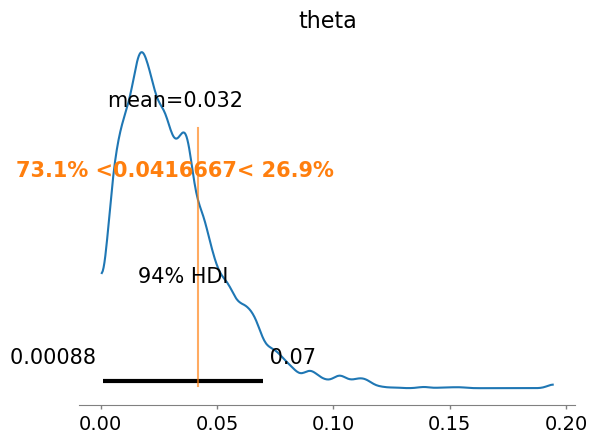

In [18]:
az.plot_posterior(trace, ref_val=1/24)

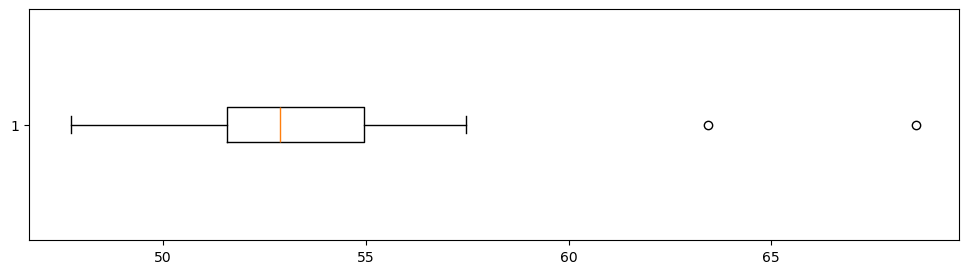

In [19]:
data = np.loadtxt("data/chemical_shifts.csv")
_, ax = plt.subplots(figsize=(12, 3))
ax.boxplot(data, vert=False)
plt.savefig("../fig/boxplot.png")

In [20]:
with pm.Model() as model_g:
    mu = pm.Uniform('mu', lower=40, upper=70)
    sigma = pm.HalfNormal('sigma', sigma=5)
    Y = pm.Normal('Y', mu=mu, sigma=sigma, observed=data)
    idata_g = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [21]:
display(idata_g)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'sigma'}>],
      dtype=object)

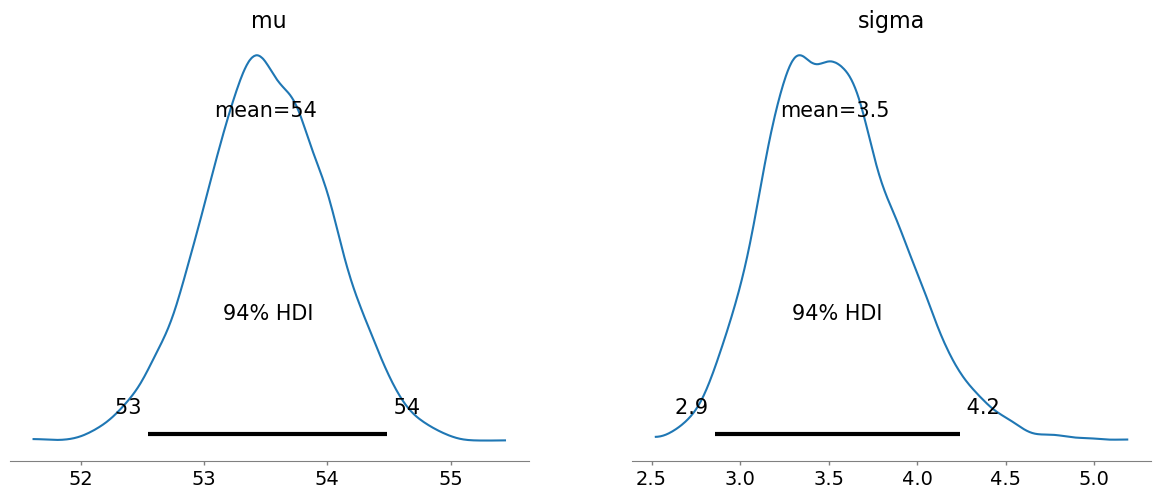

In [22]:
az.plot_posterior(idata_g)

array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

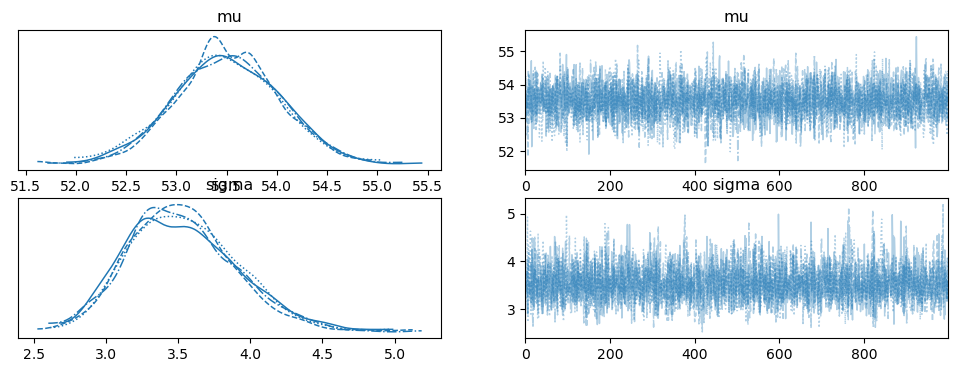

In [23]:
az.plot_trace(idata_g)

array([[<Axes: >, None],
       [<Axes: xlabel='mu', ylabel='sigma'>, <Axes: >]], dtype=object)

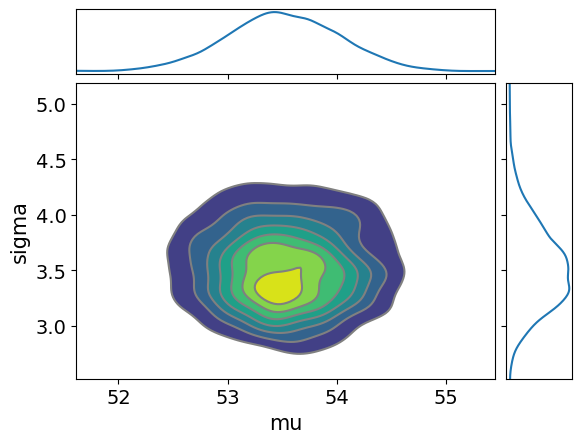

In [24]:
az.plot_pair(idata_g, kind='kde', marginals=True)

In [25]:
az.summary(idata_g)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,53.503,0.516,52.549,54.487,0.008,0.006,3939.0,2561.0,1.0
sigma,3.534,0.379,2.857,4.241,0.006,0.004,3746.0,2687.0,1.0


In [26]:
pm.sample_posterior_predictive(idata_g, model=model_g, extend_inferencedata=True)

Sampling: [Y]


Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

<Axes: xlabel='Y / Y'>

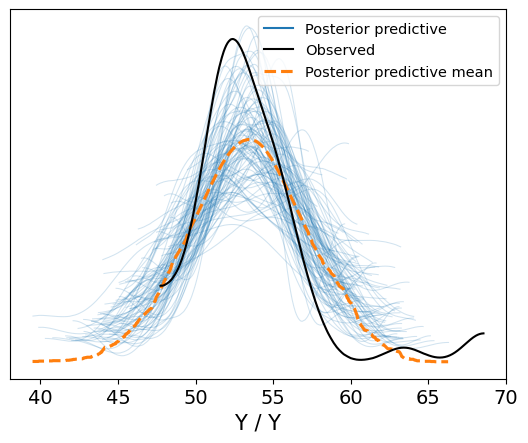

In [27]:
az.plot_ppc(idata_g, num_pp_samples=100)

In [28]:
with pm.Model() as model_t:
    mu = pm.Uniform('mu', 40, 75)
    sigma = pm.HalfNormal('sigma', sigma=10)
    nu = pm.Exponential('nu', 1/30)
    y = pm.StudentT('y', nu=nu, mu=mu, sigma=sigma, observed=data)
    idata_t = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, nu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>]],
      dtype=object)

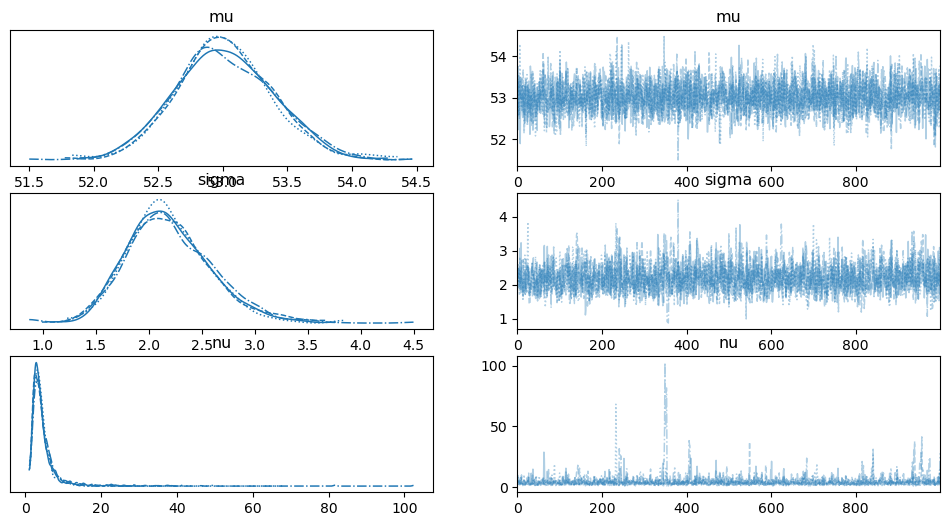

In [29]:
az.plot_trace(idata_t)

In [30]:
az.summary(idata_t)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,53.014,0.376,52.315,53.713,0.007,0.005,3172.0,2840.0,1.0
sigma,2.191,0.396,1.464,2.925,0.008,0.006,2515.0,2354.0,1.0
nu,4.615,4.352,1.035,9.108,0.131,0.098,2239.0,1769.0,1.0


array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'sigma'}>,
       <Axes: title={'center': 'nu'}>], dtype=object)

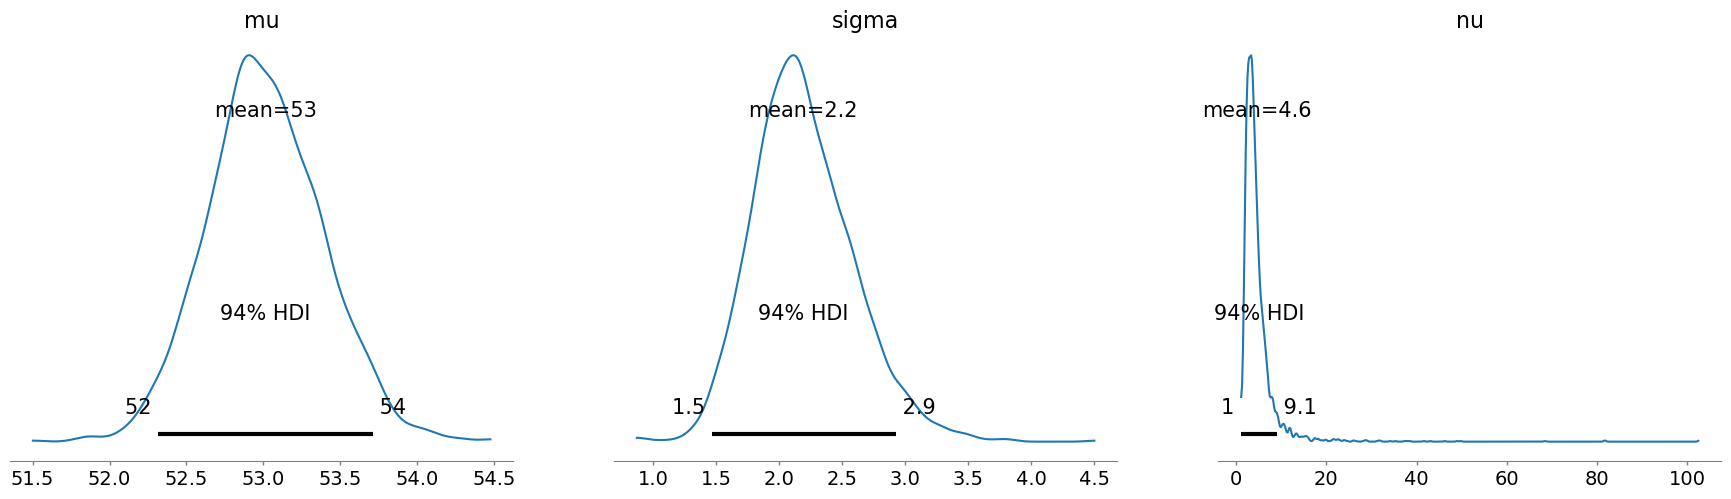

In [31]:
az.plot_posterior(idata_t)

In [32]:
pm.sample_posterior_predictive(idata_t, model=model_t, extend_inferencedata=True)

Sampling: [y]


Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

(40.0, 70.0)

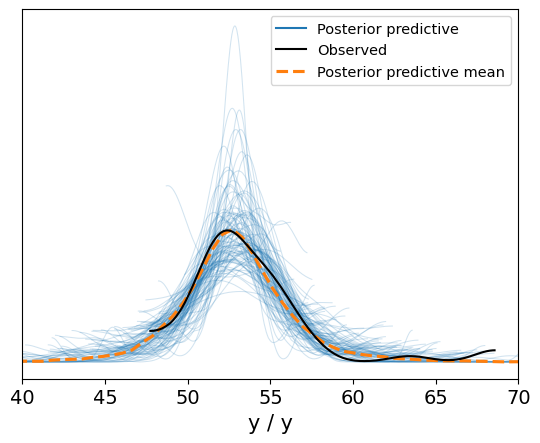

In [33]:
ax = az.plot_ppc(idata_t, num_pp_samples=100)
ax.set_xlim(40, 70)

In [34]:
display(model_g)
display(idata_g)

   mu ~ Uniform(40, 70)
sigma ~ HalfNormal(0, 5)
    Y ~ Normal(mu, sigma)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [35]:
posterior = idata_g.posterior
display(posterior)
posterior.sel(draw=0, chain=[0, 2])

<xarray.Dataset>
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999
Data variables:
    mu       (chain, draw) float64 54.12 52.89 53.78 53.28 ... 52.96 53.26 53.26
    sigma    (chain, draw) float64 4.014 3.362 3.636 3.535 ... 4.069 3.281 3.281
Attributes:
    created_at:                 2025-04-14T07:57:19.489966
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1.682145595550537
    tuning_steps:               1000

<xarray.Dataset>
Dimensions:  (chain: 2)
Coordinates:
  * chain    (chain) int64 0 2
    draw     int64 0
Data variables:
    mu       (chain) float64 54.12 54.04
    sigma    (chain) float64 4.014 3.761
Attributes:
    created_at:                 2025-04-14T07:57:19.489966
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1.682145595550537
    tuning_steps:               1000

In [36]:
posterior.sel(draw=slice(0, 100))

<xarray.Dataset>
Dimensions:  (chain: 4, draw: 101)
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 9 ... 91 92 93 94 95 96 97 98 99 100
Data variables:
    mu       (chain, draw) float64 54.12 52.89 53.78 53.28 ... 53.49 54.53 53.47
    sigma    (chain, draw) float64 4.014 3.362 3.636 3.535 ... 3.476 3.501 3.899
Attributes:
    created_at:                 2025-04-14T07:57:19.489966
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1.682145595550537
    tuning_steps:               1000

In [37]:
posterior.mean()

<xarray.Dataset>
Dimensions:  ()
Data variables:
    mu       float64 53.5
    sigma    float64 3.534

In [38]:
posterior.mean("draw")

<xarray.Dataset>
Dimensions:  (chain: 4)
Coordinates:
  * chain    (chain) int64 0 1 2 3
Data variables:
    mu       (chain) float64 53.5 53.47 53.52 53.51
    sigma    (chain) float64 3.535 3.55 3.523 3.527

In [39]:
stacked = az.extract(idata_g)
stacked

<xarray.Dataset>
Dimensions:  (sample: 4000)
Coordinates:
  * sample   (sample) object MultiIndex
  * chain    (sample) int64 0 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 0 1 2 3 4 5 6 7 ... 992 993 994 995 996 997 998 999
Data variables:
    mu       (sample) float64 54.12 52.89 53.78 53.28 ... 52.96 53.26 53.26
    sigma    (sample) float64 4.014 3.362 3.636 3.535 ... 4.069 3.281 3.281
Attributes:
    created_at:                 2025-04-14T07:57:19.489966
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1.682145595550537
    tuning_steps:               1000

In [40]:
az.extract(idata_g, num_samples=100)

<xarray.Dataset>
Dimensions:  (sample: 100)
Coordinates:
  * sample   (sample) object MultiIndex
  * chain    (sample) int64 3 1 3 2 0 0 3 1 2 1 3 3 ... 2 0 2 1 1 3 3 0 1 0 0 0
  * draw     (sample) int64 380 736 316 275 740 829 ... 614 974 155 86 371 768
Data variables:
    mu       (sample) float64 53.51 53.77 53.54 54.39 ... 53.7 53.55 53.96 53.68
    sigma    (sample) float64 3.448 3.586 3.472 2.945 ... 3.488 3.615 3.502
Attributes:
    created_at:                 2025-04-14T07:57:19.489966
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1.682145595550537
    tuning_steps:               1000

In [41]:
tips = pd.read_csv("data/tips.csv")
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [42]:
categories = np.array(['Thur', "Fri", "Sat", "Sun"])
tip = tips['tip'].values
idx = pd.Categorical(tips['day'], categories=categories).codes
display(idx)
display(categories)

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0], dtype=int8)

array(['Thur', 'Fri', 'Sat', 'Sun'], dtype='<U4')

In [43]:
with pm.Model() as comparing_groups:
    mu = pm.Normal("mu", mu=0, sigma=10, shape=4)
    sigma = pm.HalfNormal("sigma", sigma=10, shape=4)
    y = pm.Normal("y", mu=mu[idx], sigma=sigma[idx], observed=tip)

In [44]:
coords = {"days": categories, "days_flat": categories[idx]}
display(coords)

with pm.Model(coords=coords) as comparing_groups:
    mu = pm.HalfNormal("mu", sigma=5, dims="days")
    sigma = pm.HalfNormal("sigma", sigma=1, dims="days")
    y = pm.Gamma("y", mu=mu[idx], sigma=sigma[idx], observed=tip, dims="days_flat")

    idata_cg = pm.sample()
    idata_cg.extend(pm.sample_posterior_predictive(idata_cg))

{'days': array(['Thur', 'Fri', 'Sat', 'Sun'], dtype='<U4'),
 'days_flat': array(['Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun',
        'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun',
        'Sun', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sun', 'Sun', 'Sun', 'Sun',
        'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun',
        'Sun', 'Sun', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Thur', 'Thur', 'Thur', 'Thur',
        'Thur', 'Thur', 'Thur', 'Thur', 'Thur', 'Thur', 'Thur', 'Thur',
        'Thur', 'Fri', 'Fri', 'Fri', 'Fri', 'Fri', 'Fri', 'Fri', 'Fri',
        'Fri', 'Fri', 'Fri', 'Fri', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
        'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sun', 'Sun', 'Sun', 'Sun'

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Sampling: [y]


In [45]:
display(idata_cg)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

array([<Axes: xlabel='y / y\nSun'>, <Axes: xlabel='y / y\nSat'>,
       <Axes: xlabel='y / y\nThur'>, <Axes: xlabel='y / y\nFri'>],
      dtype=object)

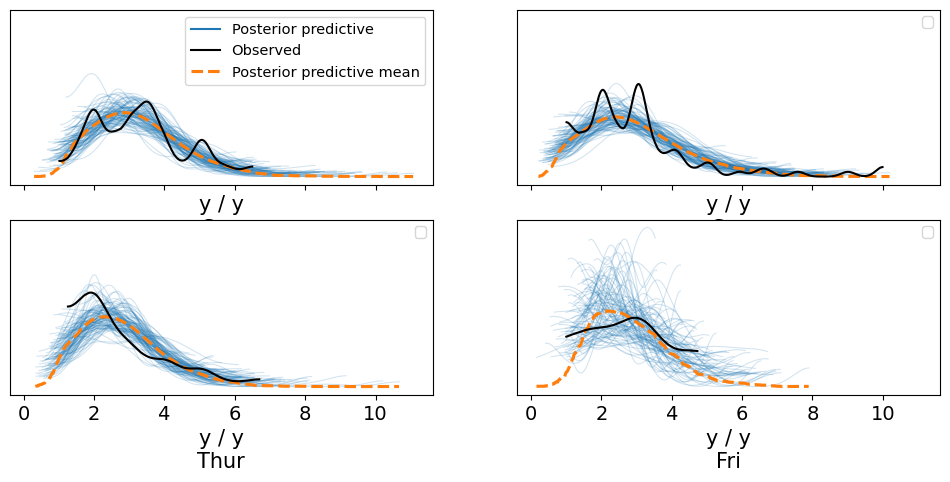

In [46]:

_, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True, sharey=True)
az.plot_ppc(idata_cg, num_pp_samples=100, 
            coords={"days_flat": categories},
            flatten=[], ax=axes)

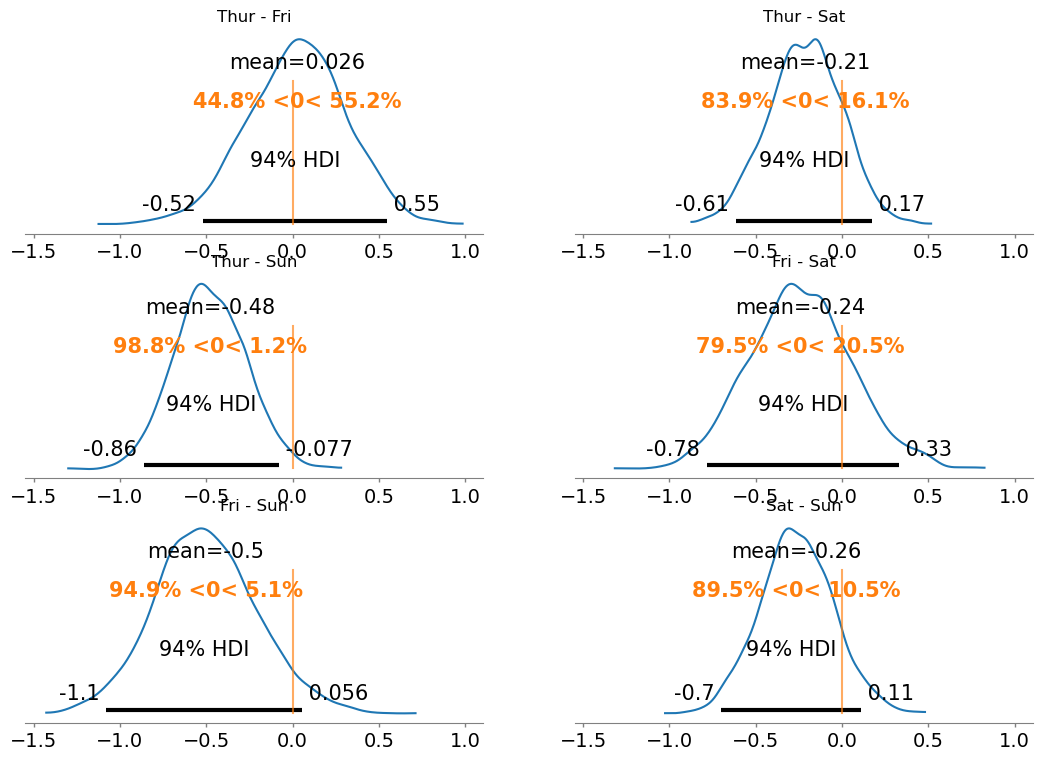

In [49]:
cg_posterior = az.extract(idata_cg)

dist = pz.Normal(0, 1)

comparisons = [(categories[i], categories[j]) for i in range(4) for j in range(i+1, 4)]

_, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)

for (i, j), ax in zip(comparisons, axes.ravel()):
    means_diff = cg_posterior["mu"].sel(days=i) - cg_posterior['mu'].sel(days=j)
    
    d_cohen = (means_diff /
               np.sqrt((cg_posterior["sigma"].sel(days=i)**2 + 
                        cg_posterior["sigma"].sel(days=j)**2) / 2)
              ).mean().item()
    
    ps = dist.cdf(d_cohen/(2**0.5))
    az.plot_posterior(means_diff.values, ref_val=0, ax=ax)
    ax.set_title(f"{i} - {j}")
    ax.plot(0, label=f"Cohen's d = {d_cohen:.2f}\nProb sup = {ps:.2f}", alpha=0)
    # ax.legend(loc=1)

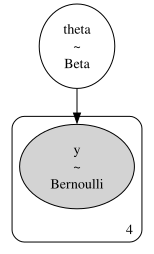

In [51]:
our_first_model.to_graphviz()

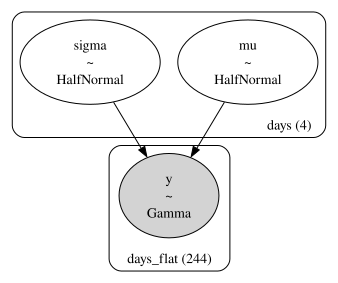

In [50]:
comparing_groups.to_graphviz()

In [52]:
idata_cg

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [58]:
posterior = idata_cg.posterior
posterior

<xarray.Dataset>
Dimensions:  (chain: 4, draw: 1000, days: 4)
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999
  * days     (days) <U4 'Thur' 'Fri' 'Sat' 'Sun'
Data variables:
    mu       (chain, draw, days) float64 2.758 2.847 3.075 ... 3.288 2.961 3.332
    sigma    (chain, draw, days) float64 1.115 1.091 1.452 ... 1.613 1.397 1.402
Attributes:
    created_at:                 2025-04-14T07:57:47.556573
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              3.287271738052368
    tuning_steps:               1000

In [62]:
posterior.sel(days='Sun').mean()

<xarray.Dataset>
Dimensions:  ()
Coordinates:
    days     <U4 'Sun'
Data variables:
    mu       float64 3.26
    sigma    float64 1.261

In [66]:
posterior.mean('days')

<xarray.Dataset>
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999
Data variables:
    mu       (chain, draw) float64 2.968 2.863 2.762 3.023 ... 2.805 2.755 3.169
    sigma    (chain, draw) float64 1.18 1.085 1.103 1.267 ... 1.116 1.098 1.397